In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [33]:
import pandas as pd

data_file_path = "auto-mpg.data"
csv_file_path = "output_data.csv"

df_csv = pd.read_csv(csv_file_path)

df_csv = df_csv.drop(["car_name","model_year","origin"],axis=1)

df_csv['horsepower'] = pd.to_numeric(df_csv['horsepower'], errors='coerce')
print(df_csv.head())
print(df_csv.info())


    mpg  cylinders  displacement  horsepower  weight  acceleration
0  18.0          8         307.0       130.0  3504.0          12.0
1  15.0          8         350.0       165.0  3693.0          11.5
2  18.0          8         318.0       150.0  3436.0          11.0
3  16.0          8         304.0       150.0  3433.0          12.0
4  17.0          8         302.0       140.0  3449.0          10.5
<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    float64
 5   acceleration  398 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 18.8 KB
None


In [34]:
df_csv.corr()

,mpg,cylinders,displacement,horsepower,weight,acceleration
mpg,1.000000,-0.775396,-0.804203,-0.778427,-0.831741,0.420289
cylinders,-0.775396,1.000000,0.950721,0.842983,0.896017,-0.505419
displacement,-0.804203,0.950721,1.000000,0.897257,0.932824,-0.543684
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196
weight,-0.831741,0.896017,0.932824,0.864538,1.000000,-0.417457
acceleration,0.420289,-0.505419,-0.543684,-0.689196,-0.417457,1.000000


<Axes: >

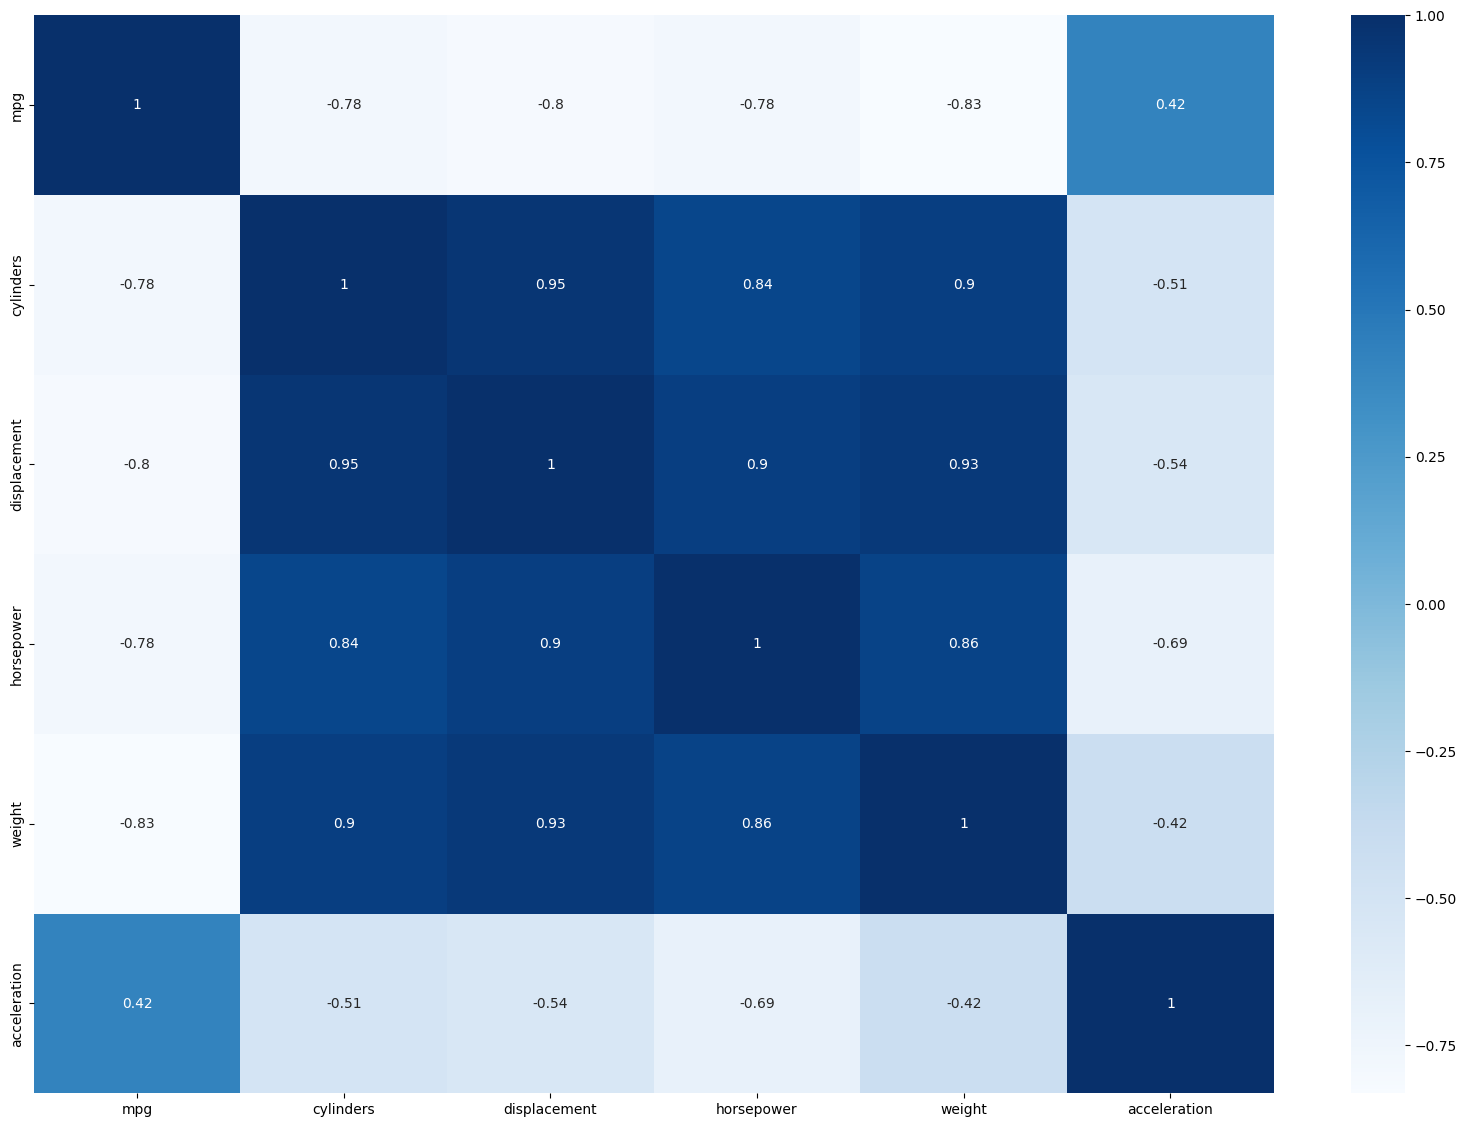

In [35]:
plt.figure(figsize=(20,14))

sns.heatmap(df_csv.corr(),annot=True,cmap='Blues')

Text(0.5, 0, 'displacement')

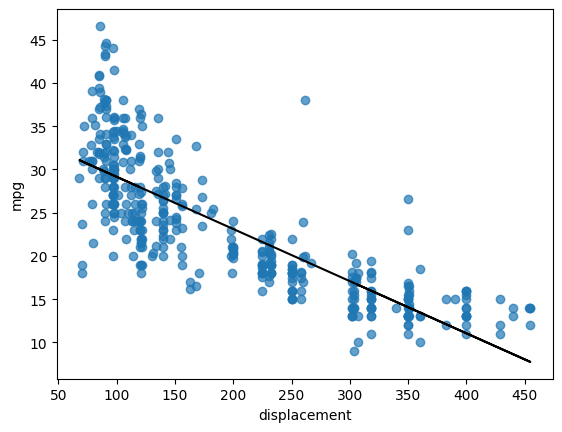

In [ ]:
plt.scatter(df_csv['displacement'],df_csv['mpg'],alpha=0.7)


feature = df_csv.drop("mpg",axis=1).values
target = df_csv['mpg'].values

# plotting mpg against dsiplacement
reg = LinearRegression()

feature_mpg = feature[:,1]
feature_mpg = feature_mpg.reshape(-1,1)

reg.fit(feature_mpg,target)
predictions = reg.predict(feature_mpg)
plt.plot(feature_mpg,predictions,color='black')


plt.ylabel("mpg")
plt.xlabel("displacement")

# Regression-Tree 

In [43]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import  mean_squared_error as MSE


X_train , X_test , y_train , y_test = train_test_split(feature,target,test_size=0.2,random_state=3)

dt = DecisionTreeRegressor(max_depth=4,min_samples_leaf=0.1,random_state=3)

# Fit dt to training set
dt.fit(X_train, y_train)

# Predict test-sets labels
y_pred = dt.predict(X_test)

# Compute test-set MSE
mse_dt = MSE(y_test,y_pred)

# Compute test set RMSE
rmse_dt = mse_dt**(0.5)

print(rmse_dt)

4.669852837156957
